# Credit Risk Prediction 

# 1. Introduction and Problem Statement


# Introduction
Financial institutions such as banks and credit companies provide loans to customers. However, some customers fail to repay their loans, causing financial losses. Machine learning can help banks predict whether a loan applicant is likely to default before approving the loan.

This project uses machine learning techniques to analyze applicant information such as income, education, loan amount, and credit history to predict loan approval or default risk.

# Problem Statement

The objective of this project is to build a machine learning model that predicts whether a loan applicant is likely to repay or default on a loan.

The project aims to:

Analyze loan applicant data    
Identify important factors affecting loan approval     
Train a classification model     
Evaluate prediction performance using accuracy and confusion matrix   

step 1:Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split    #scikit-learn (often called sklearn) is an open-source Python library primarily used for machine learning and data modeling.
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

Step 2: Load Dataset

In [5]:
df=pd.read_csv("loan_dataset.csv")

In [6]:
#view fisrt 5 rows 
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [8]:
#Check dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  str    
 2   marital_status        20000 non-null  str    
 3   education_level       20000 non-null  str    
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  str    
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  str    
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  str    
 15  num_of_open_accounts  20000 no

In [9]:
# missing values
df.isnull().sum()

age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64

# Exploratory Data Analysis (EDA)

EDA helps understand patterns and relationships in data.

# 1 Loan Amount Distribution

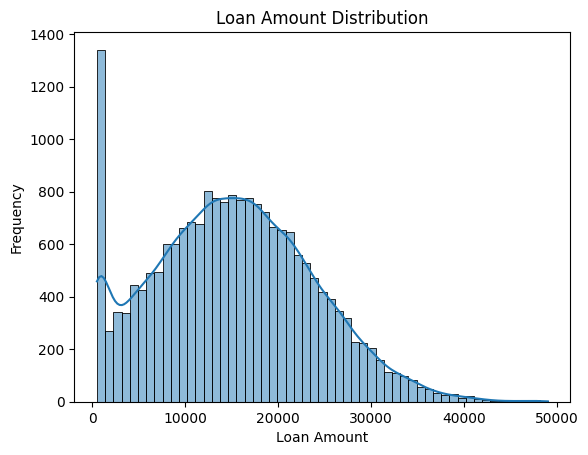

In [26]:
sns.histplot(df['loan_amount'], kde=True)

plt.title("Loan Amount Distribution")

plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

Explanation:   
Histogram shows frequency of loan amounts     
KDE line shows data distribution smoothly     
Insights:   
Most people apply for medium-sized loans    
Very high loans are fewer   

# 2 Education vs Loan Status

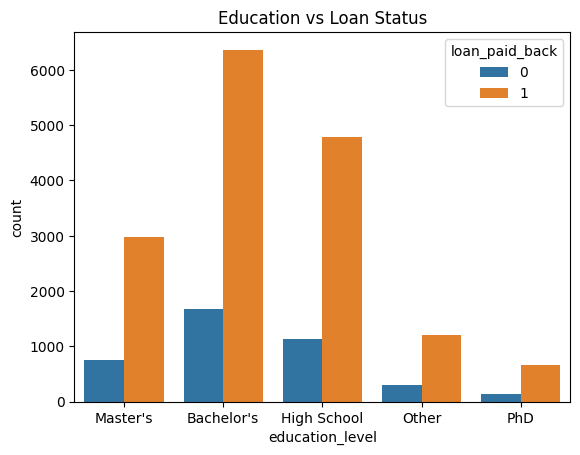

In [27]:
sns.countplot(
    x='education_level',
    hue='loan_paid_back',
    data=df
)

plt.title("Education vs Loan Status")

plt.show()

Insight:     
Graduates may have higher loan approval rates    
Education affects repayment capability   

# 3 Applicant Income Distribution

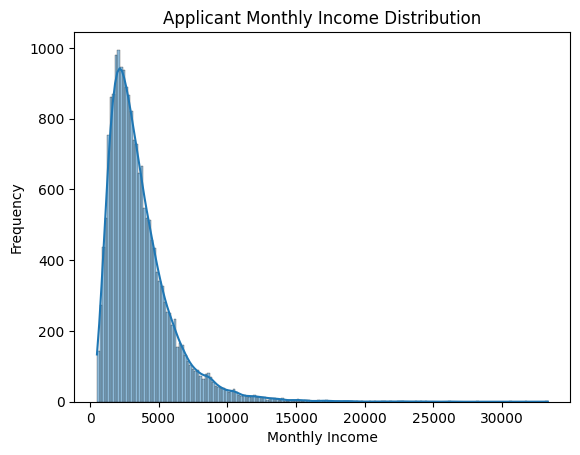

In [28]:
# Monthly Income Distribution
sns.histplot(df['monthly_income'], kde=True)

plt.title("Applicant Monthly Income Distribution")

plt.xlabel("Monthly Income")
plt.ylabel("Frequency")

plt.show()

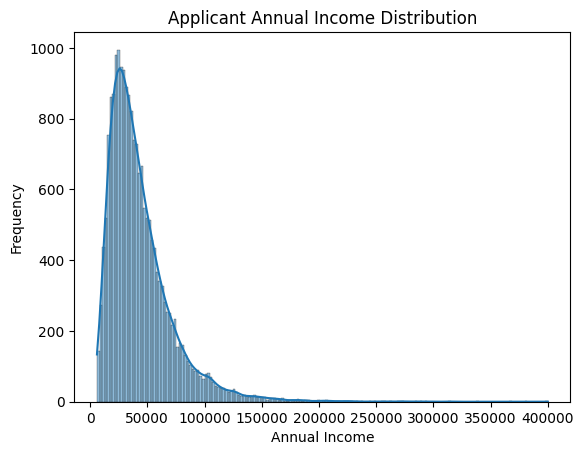

In [29]:
# Annual income Distribution
sns.histplot(df['annual_income'], kde=True)

plt.title("Applicant Annual Income Distribution")

plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()


Most applicants belong to middle-income groups     
Higher income often increases approval chances    

#  Train a Classification Model

Step 1: Separate Features and Target

In [41]:
X = df.drop('loan_paid_back', axis=1)  #     x= input features           y = target variable

y = df['loan_paid_back']

Step 2: Split Dataset

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
) 

#Explanation    >80% data used for training  >20% data used for testing

3 Train Logistic Regression

Why Encoding Is Important

Machine learning models work with:

Numbers
Mathematical calculations

They cannot directly understand text values like:

Female  
Bachelor      
Married   

Encoding converts categories into machine-readable numeric values.

In [23]:
df.dtypes

age                       int64
gender                      str
marital_status              str
education_level             str
annual_income           float64
monthly_income          float64
employment_status           str
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
loan_purpose                str
interest_rate           float64
loan_term                 int64
installment             float64
grade_subgrade              str
num_of_open_accounts      int64
total_credit_limit      float64
current_balance         float64
delinquency_history       int64
public_records            int64
num_of_delinquencies      int64
loan_paid_back            int64
dtype: object

In [44]:
from sklearn.preprocessing import LabelEncoder   #Use Label Encoding

le = LabelEncoder()

In [45]:
for col in df.columns:   #Encode All Categorical Columns
    
    if df[col].dtype == 'str':
        
        df[col] = le.fit_transform(df[col])

In [46]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

c:\ProgramData\miniconda3\envs\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Step 4: Make Predictions

In [47]:
y_pred = model.predict(X_test)

# Evaluate the Model

a) Accuracy Score

In [48]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.796


Formula

Accuracy=
TP+TN/ FP+FN+TP+TN
	​


Explanation

Accuracy measures:

Correct predictions / total predictions

Example:

90 correct predictions out of 100
Accuracy = 90%

b) Confusion Matrix

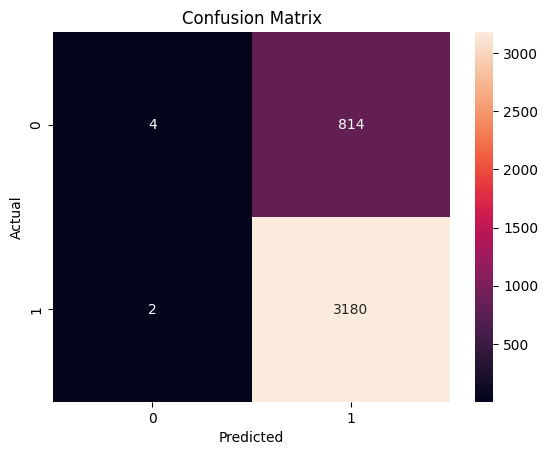

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Understanding Confusion Matrix       
Term	              Meaning     
True Positive (TP)	   Correctly predicted approved loan   
True Negative (TN)	   Correctly predicted rejected loan     
False Positive (FP)	   Wrongly approved risky applicant        
False Negative (FN)	   Wrongly rejected safe applicant       

Conclusion   

This project successfully developed a machine learning model for predicting loan approval and credit risk. 

Key findings include:

Credit history strongly affects loan approval.  
Applicant income and loan amount also influence predictions.   
Logistic Regression performed effectively for binary classification.     
The model achieved good accuracy in predicting loan outcomes.    

The project demonstrates the importance of:

Data cleaning   
Exploratory Data Analysis (EDA)     
Feature engineering     
Machine learning classification    
Model evaluation     

This type of predictive system can help banks reduce financial risk and improve loan approval decisions.